In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [4]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "../stations/" + filename_lo
    filepath_ssc = "../stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [4]:
station = "SAR003"

#print(data_lo[station].data_vars)
print(data_ssc[station].data_vars)

Data variables:
    PAR                           (time_counter, deptht) float32 58kB ...
    turbidity                     (time_counter, deptht) float32 58kB ...
    dissolved_inorganic_carbon    (time_counter, deptht) float32 58kB ...
    total_alkalinity              (time_counter, deptht) float32 58kB ...
    dissolved_oxygen              (time_counter, deptht) float32 58kB ...
    votemper                      (time_counter, deptht) float32 58kB ...
    vosaline                      (time_counter, deptht) float32 58kB ...
    sigma_theta                   (time_counter, deptht) float32 58kB ...
    e3t                           (time_counter, deptht) float32 58kB ...
    nitrate                       (time_counter, deptht) float32 58kB ...
    ammonium                      (time_counter, deptht) float32 58kB ...
    silicon                       (time_counter, deptht) float32 58kB ...
    diatoms                       (time_counter, deptht) float32 58kB ...
    flagellates       

In [ ]:
for station in station_names:
    ds = data_lo[station]
    
    max_depth = ds["z_rho"].min().item()   # deepest rho level (m)
    h = ds["h"].item()                     # bathymetry (m)

    print(f"{station:6s}: deepest z_rho = {max_depth:7.2f} m, bathymetry = {h:7.2f} m")

SAR003: deepest z_rho = -118.90 m, bathymetry =  121.58 m
PSS019: deepest z_rho =  -60.88 m, bathymetry =   62.23 m
SKG003: deepest z_rho =  -11.53 m, bathymetry =   11.76 m
HCB004: deepest z_rho =  -30.89 m, bathymetry =   31.55 m
HCB003: deepest z_rho =  -95.71 m, bathymetry =   97.85 m
ADM003: deepest z_rho = -203.12 m, bathymetry =  207.72 m
CMB003: deepest z_rho = -131.46 m, bathymetry =  134.42 m
GOR001: deepest z_rho = -163.00 m, bathymetry =  166.68 m
CSE001: deepest z_rho =  -46.35 m, bathymetry =   47.36 m
EAP001: deepest z_rho = -198.89 m, bathymetry =  203.39 m
SIN001: deepest z_rho =  -12.31 m, bathymetry =   12.56 m
PSB003: deepest z_rho =  -67.06 m, bathymetry =   68.55 m


In [39]:
for station in station_names:
    ds = data_ssc[station]

    # First time step (bathymetry doesn't change with time)
    do = ds["dissolved_oxygen"].isel(time_counter=0).values
    z = ds["deptht"].values
    e3t = ds["e3t"].isel(time_counter=0).values

    # Keep only valid water cells
    valid = np.isfinite(do) & np.isfinite(e3t) & (e3t > 0) & (do > 0)

    z_valid = z[valid]
    e3t_valid = e3t[valid]

    # Deepest tracer level and estimated bottom interface
    deepest_deptht = z_valid[-1]
    estimated_bottom = deepest_deptht + e3t_valid[-1] / 2

    print(
        f"{station:6s}: deepest deptht = {deepest_deptht:7.2f} m, "
        f"estimated bathymetry = {estimated_bottom:7.2f} m"
    )

SAR003: deepest deptht =  121.87 m, estimated bathymetry =  134.16 m
PSS019: deepest deptht =   98.06 m, estimated bathymetry =  102.57 m
SKG003: deepest deptht =   18.01 m, estimated bathymetry =   18.66 m
HCB004: deepest deptht =   34.69 m, estimated bathymetry =   38.64 m
HCB003: deepest deptht =  121.87 m, estimated bathymetry =  127.99 m
ADM003: deepest deptht =  199.57 m, estimated bathymetry =  207.07 m
CMB003: deepest deptht =  147.09 m, estimated bathymetry =  148.79 m
GOR001: deepest deptht =  173.11 m, estimated bathymetry =  175.97 m
CSE001: deepest deptht =   44.52 m, estimated bathymetry =   45.70 m
EAP001: deepest deptht =  199.57 m, estimated bathymetry =  208.56 m
SIN001: deepest deptht =   10.50 m, estimated bathymetry =   10.99 m
PSB003: deepest deptht =   58.48 m, estimated bathymetry =   60.15 m


In [5]:
print(f"{'Station':8s} {'LO h (m)':>10s} {'SSC h (m)':>10s} {'SSC-LO (m)':>12s}")

for station in station_names:

    # ----- LiveOcean -----
    ds_lo = data_lo[station]
    h_lo = ds_lo["h"].item()

    # ----- SalishSeaCast -----
    ds_ssc = data_ssc[station]

    do = ds_ssc["dissolved_oxygen"].isel(time_counter=0).values
    z = ds_ssc["deptht"].values
    e3t = ds_ssc["e3t"].isel(time_counter=0).values

    valid = np.isfinite(do) & np.isfinite(e3t) & (e3t > 0) & (do > 0)

    z_valid = z[valid]
    e3t_valid = e3t[valid]

    h_ssc = z_valid[-1] + e3t_valid[-1] / 2

    print(
        f"{station:8s}"
        f"{h_lo:10.2f}"
        f"{h_ssc:10.2f}"
        f"{h_ssc - h_lo:12.2f}"
    )

Station    LO h (m)  SSC h (m)   SSC-LO (m)
SAR003      121.58    134.16       12.58
PSS019       62.23    102.57       40.35
SKG003       11.76     18.66        6.90
HCB004       31.55     38.64        7.09
HCB003       97.85    127.99       30.14
ADM003      207.72    207.07       -0.66
CMB003      134.42    148.79       14.37
GOR001      166.68    175.97        9.29
CSE001       47.36     45.70       -1.67
EAP001      203.39    208.56        5.17
SIN001       12.56     10.99       -1.57
PSB003       68.55     60.15       -8.40


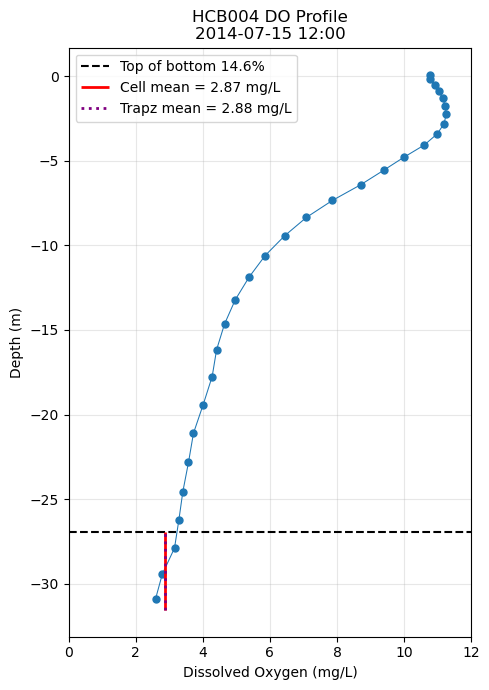

In [ ]:
station = "HCB004" # "SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"

plt.figure(figsize=(5, 7))

ds = data_lo[station]

# select values in september when DO is low
target = np.datetime64("2014-07-16")
itime = np.argmin(np.abs(ds["ocean_time"].values - target))

# choose timestep
do = (ds["oxygen"].isel(ocean_time=itime) * 0.032).values  # µmol/L -> mg/L
z = (ds["z_rho"].isel(ocean_time=itime)).values
z_w = (ds["z_w"].isel(ocean_time=itime)).values

# Plot rho points
plt.plot(do, z, '-o', lw=0.75, markersize=5)

# Bottom 14.6% of the water column
h = ds["h"].item() # total water column depth
z_146 = -0.854 * h
z_bot=-h

# z_w gives interface depths
z_lower = z_w[:-1] # selects everything except the last value
z_upper = z_w[1:]  # selects everything except the first value

overlap = np.maximum(
    0, # cells above the bottom 14.6% have negative overlap, set to 0 so don't contribute to the average
    np.minimum(z_upper, z_146) - np.maximum(z_lower, z_bot)
)

bottom_mean_do = np.sum(do * overlap) / np.sum(overlap)

# Sort by depth for interpolation
idx = np.argsort(z)
z_sorted = z[idx]
do_sorted = do[idx]

# Interpolate DO at layer boundaries
do_bot = np.interp(z_bot, z_sorted, do_sorted)
do_146 = np.interp(z_146, z_sorted, do_sorted)

# Keep rho points inside the bottom 14.6% layer
mask = (z_sorted >= z_bot) & (z_sorted <= z_146)

z_trapz = np.concatenate(([z_bot], z_sorted[mask], [z_146]))
do_trapz = np.concatenate(([do_bot], do_sorted[mask], [do_146]))

# Integrate concentration over depth and divide by layer thickness
bottom_mean_do_trapz = np.trapezoid(do_trapz, z_trapz) / (z_146 - z_bot)

plt.axhline(
    z_146,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Top of bottom 14.6%"
)

plt.vlines(
    x=bottom_mean_do,
    ymin=z_bot,
    ymax=z_146,
    color="red",
    linewidth=2,
    label=f"Cell mean = {bottom_mean_do:.2f} mg/L"
)

plt.vlines(
    x=bottom_mean_do_trapz,
    ymin=z_bot,
    ymax=z_146,
    color="purple",
    linewidth=2,
    linestyle=":",
    label=f"Trapz mean = {bottom_mean_do_trapz:.2f} mg/L"
)

time_str = ds["ocean_time"].isel(ocean_time=itime).dt.strftime("%Y-%m-%d %H:%M").item()
plt.title(f"{station} DO Profile\n{time_str}")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.xlim(0, 12)
plt.ylabel("Depth (m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# thickness of each cell
z_w = ds["z_w"].isel(ocean_time=0)
z_rho = ds["z_rho"].isel(ocean_time=0)
print(z_w[0].values, z_w[-1].values)
print(z_rho[0].values, z_rho[-1].values)

-207.72449278124893 0.13652192056179047
-203.12175305373194 -0.06135181147526794


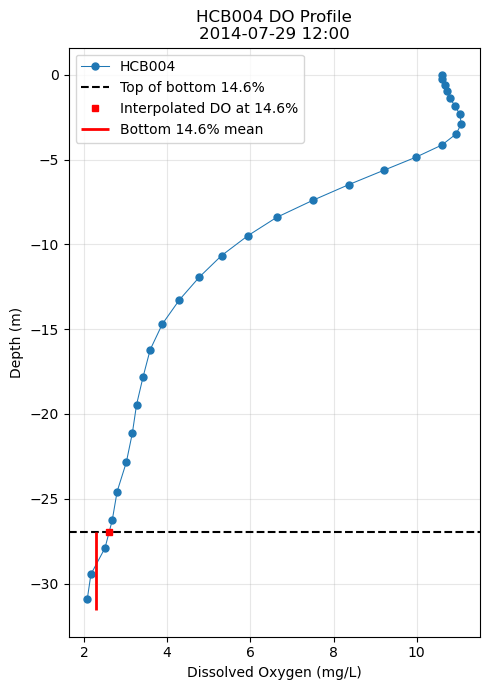

In [ ]:
station = "HCB004" # "SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"

plt.figure(figsize=(5, 7))

ds = data_lo[station]

# select values in september when DO is low
target = np.datetime64("2014-07-30")
itime = np.argmin(np.abs(ds["ocean_time"].values - target))

# choose timestep
do = (ds["oxygen"].isel(ocean_time=itime) * 0.032).values  # µmol/L -> mg/L
z = (ds["z_rho"].isel(ocean_time=itime)).values
z_w = (ds["z_w"].isel(ocean_time=itime)).values

# Plot rho points
plt.plot(do, z, '-o', lw=0.75, markersize=5)

# Bottom 14.6% of the water column
h = ds["h"].item() # total water column depth
z_146 = -0.854 * h
z_bot=-h

plt.axhline(
    z_146,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Top of bottom 14.6%"
)

# Sort by depth for interpolation
idx = np.argsort(z)
z_sorted = z[idx]
do_sorted = do[idx]

# Interpolate DO at layer boundaries
do_bot = np.interp(z_bot, z_sorted, do_sorted)
do_146 = np.interp(z_146, z_sorted, do_sorted)

# Keep rho points inside the bottom 14.6% layer
mask = (z_sorted >= z_bot) & (z_sorted <= z_146)

z_trapz = np.concatenate(([z_bot], z_sorted[mask], [z_146]))
do_trapz = np.concatenate(([do_bot], do_sorted[mask], [do_146]))

# Integrate concentration over depth and divide by layer thickness
bottom_mean_do_trapz = np.trapezoid(do_trapz, z_trapz) / (z_146 - z_bot)

plt.plot(do_146, z_146, "s", markersize=5, color="red", label="Interpolated DO at 14.6%")

plt.vlines(
    x=bottom_mean_do_trapz,
    ymin=z_bot,
    ymax=z_146,
    color="red",
    linewidth=2,
    label="Bottom 14.6% mean"
)
time_str = ds["ocean_time"].isel(ocean_time=itime).dt.strftime("%Y-%m-%d %H:%M").item()
plt.title(f"{station} DO Profile\n{time_str}")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Depth (m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
# trplt.show()

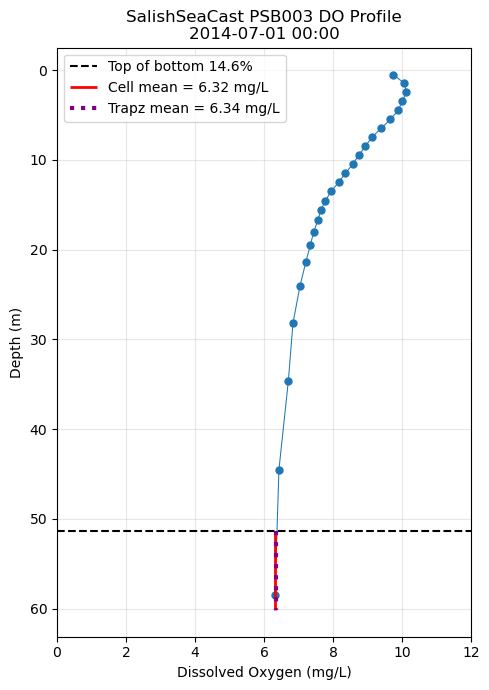

In [ ]:
# same method with salishseacast

station = "PSB003" # "SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"

plt.figure(figsize=(5, 7))

ds = data_ssc[station]

# select values in september when DO is low
target = np.datetime64("2014-07-01")
itime = np.argmin(np.abs(ds["time_counter"].values - target))

# choose timestep
do = (ds["dissolved_oxygen"].isel(time_counter=itime) * 0.032).values  # µmol/L -> mg/L
z = ds["deptht"].values
e3t = ds["e3t"].isel(time_counter=itime).values

# mask out below bottom values (40 layers but Puget Sound is shallower, 0 for layers below bathymetry)
valid = np.isfinite(do) & np.isfinite(e3t) & (e3t > 0) & (do > 0)

do = do[valid]
z = z[valid]
e3t = e3t[valid]

# e3t gives cell thicknesses
z_upper = z - e3t / 2  # shallower cell interface
z_lower = z + e3t / 2 # deeper cell interface

z_bot = z_lower[-1]  # bottom of the water column from deepest valid cell

# Bottom 14.6% of the water column
z_146 = 0.854 * z_bot

overlap = np.maximum(
    0, # cells above the bottom 14.6% have negative overlap, set to 0 so don't contribute to the average
    np.minimum(z_lower, z_bot) - np.maximum(z_upper, z_146)
)

bottom_mean_do = np.sum(do * overlap) / np.sum(overlap)

# Plot rho points
plt.plot(do, z, '-o', lw=0.75, markersize=5)

# Sort by depth for interpolation
idx = np.argsort(z)
z_sorted = z[idx]
do_sorted = do[idx]

# Interpolate DO at layer boundaries
do_bot = np.interp(z_bot, z_sorted, do_sorted)
do_146 = np.interp(z_146, z_sorted, do_sorted)

# Keep rho points inside the bottom 14.6% layer
mask = (z_sorted >= z_146) & (z_sorted <= z_bot)

z_trapz = np.concatenate(([z_146], z_sorted[mask], [z_bot]))
do_trapz = np.concatenate(([do_146], do_sorted[mask], [do_bot]))

# Integrate concentration over depth and divide by layer thickness
bottom_mean_do_trapz = np.trapezoid(do_trapz, z_trapz) / (z_bot - z_146)

plt.axhline(
    z_146,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Top of bottom 14.6%"
)

plt.vlines(
    x=bottom_mean_do,
    ymin=z_bot,
    ymax=z_146,
    color="red",
    linewidth=2,
    label=f"Cell mean = {bottom_mean_do:.2f} mg/L"
)

plt.vlines(
    x=bottom_mean_do_trapz,
    ymin=z_146,
    ymax=z_bot,
    color="purple",
    linewidth=3,
    linestyle=":",
    label=f"Trapz mean = {bottom_mean_do_trapz:.2f} mg/L"
)

time_str = ds["time_counter"].isel(time_counter=itime).dt.strftime("%Y-%m-%d %H:%M").item()
plt.title(f"SalishSeaCast {station} DO Profile\n{time_str}")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.xlim(0, 12)
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [48]:
print(data_ssc['HCB003'])

<xarray.Dataset> Size: 1MB
Dimensions:                       (time_counter: 365, deptht: 40)
Coordinates:
  * time_counter                  (time_counter) datetime64[ns] 3kB 2014-01-0...
  * deptht                        (deptht) float64 320B 0.5 1.5 ... 414.5 441.5
Data variables: (12/19)
    PAR                           (time_counter, deptht) float32 58kB ...
    turbidity                     (time_counter, deptht) float32 58kB ...
    dissolved_inorganic_carbon    (time_counter, deptht) float32 58kB ...
    total_alkalinity              (time_counter, deptht) float32 58kB ...
    dissolved_oxygen              (time_counter, deptht) float32 58kB ...
    votemper                      (time_counter, deptht) float32 58kB ...
    ...                            ...
    flagellates                   (time_counter, deptht) float32 58kB ...
    microzooplankton              (time_counter, deptht) float32 58kB ...
    dissolved_organic_nitrogen    (time_counter, deptht) float32 58kB ...
    